# **SSL using DS8 for SSL and DS2 for down stream All Sensors**

In [ ]:
import gc
import math
import torch
from torch.utils.data import DataLoader, ConcatDataset
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

from preprocessing import CMAPSSWindowed, preprocessing
from dataloading import load_data
from Models import (
    TCNBackbone, TransformerBackbone, TCNTransformerBackbone,
    MaskedReconstructionSSL, RULHead, BinaryClassificationHead,
    init_inducing_points, EarlyStopping,
)
from Training import train_ssl, train_rul, train_cls
from Testing import test_rul, test_cls
from plots import (
    plot_ssl_history, plot_ssl_reconstruction, plot_ssl_feature_errors,
    plot_metric_curve, plot_regression_dashboard, plot_classification_dashboard,
)


### GPU check

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
Using device: cuda


### Config

In [ ]:
DATA_DIR = "../../data_set"


SSL_FILES = [f"{DATA_DIR}/N-CMAPSS_DS08a-009.h5", f"{DATA_DIR}/N-CMAPSS_DS08c-008.h5"]
RUL_FILE = f"{DATA_DIR}/N-CMAPSS_DS02-006.h5"

VAL_UNIT = 18  # held out from DS02's 6 training units for validation/early-stopping/Optuna

SSL_CHECKPOINT = "best_ssl_backbone_all.pt"
RUL_CHECKPOINT = "best_rul_gp_head_all.pt"
CLS_CHECKPOINT = "best_cls_gp_head_all.pt"

VALID_STRIDES = {50: [15, 20], 100: [30, 40], 500: [150, 200]}


## Data preprocessing


In [ ]:
def load_and_scale(filenames):

    for filename in filenames:
        W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
        if feats is None:
            feats = W_var + X_s_var + X_v_var
            print(f"Using {len(feats)} features:", feats)

        train_scaled, val_scaled, _, _ = preprocessing(True, train_df, test_df, feats)
        del train_df, test_df
        gc.collect()
        train_dfs.append(train_scaled)
        val_dfs.append(val_scaled)
    return feats, train_dfs, val_dfs


features, ssl_train_dfs, ssl_val_dfs = load_and_scale(SSL_FILES)


def build_ssl_datasets(window_size, stride):
    train_sets = [CMAPSSWindowed(df, features, window_size, stride, has_target=False) for df in ssl_train_dfs]
    val_sets = [CMAPSSWindowed(df, features, window_size, stride, has_target=False) for df in ssl_val_dfs]
    return ConcatDataset(train_sets), ConcatDataset(val_sets)



Operation time (min):  0.0484375

W_dev shape: (4885389, 4) | W_test shape: (3722997, 4)
X_s_dev shape: (4885389, 14) | X_s_test shape: (3722997, 14)
X_v_dev shape: (4885389, 14) | X_v_test shape: (3722997, 14)
A_dev shape: (4885389, 4) | A_test shape: (3722997, 4)
Using 32 features: [np.str_('alt'), np.str_('Mach'), np.str_('TRA'), np.str_('T2'), np.str_('T24'), np.str_('T30'), np.str_('T48'), np.str_('T50'), np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50'), np.str_('Nf'), np.str_('Nc'), np.str_('Wf'), np.str_('T40'), np.str_('P30'), np.str_('P45'), np.str_('W21'), np.str_('W22'), np.str_('W25'), np.str_('W31'), np.str_('W32'), np.str_('W48'), np.str_('W50'), np.str_('SmFan'), np.str_('SmLPC'), np.str_('SmHPC'), np.str_('phi')]
Data Normalization


Operation time (min):  0.027083333333333334

W_dev shape: (4299918, 4) | W_test shape: (2117819, 4)
X_s_dev shape: (4299918, 14) | X_s_test shape: (2117819, 14)
X_v_dev shape: (

### Backbone builder


In [ ]:
def build_backbone(trial, num_features):
    backbone_type = trial.suggest_categorical("backbone_type", ["tcn", "transformer", "tcn_transformer"])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)

    if backbone_type == "tcn":
        ch = trial.suggest_categorical("tcn_channels", [32, 64, 128])
        backbone = TCNBackbone(num_features=num_features, num_channels=(ch, ch, ch), dropout=dropout)

    elif backbone_type == "transformer":
        d_model = trial.suggest_categorical("tf_d_model", [32, 64, 128])
        nhead = trial.suggest_categorical("tf_nhead", [2, 4, 8])
        if d_model % nhead != 0:
            raise optuna.TrialPruned()
        num_layers = trial.suggest_int("tf_num_layers", 1, 4)
        dim_feedforward = trial.suggest_categorical("tf_dim_feedforward", [64, 128, 256])
        backbone = TransformerBackbone(num_features=num_features, d_model=d_model, nhead=nhead,
                                       num_layers=num_layers, dim_feedforward=dim_feedforward, dropout=dropout)

    else:
        ch = trial.suggest_categorical("hyb_tcn_channels", [32, 64])
        d_model = trial.suggest_categorical("hyb_d_model", [32, 64, 128])
        nhead = trial.suggest_categorical("hyb_nhead", [2, 4, 8])
        if d_model % nhead != 0:
            raise optuna.TrialPruned()
        num_layers = trial.suggest_int("hyb_num_layers", 1, 3)
        dim_feedforward = trial.suggest_categorical("hyb_dim_feedforward", [64, 128, 256])
        backbone = TCNTransformerBackbone(num_features=num_features, num_channels=(ch, ch), dropout=dropout,
                                          d_model=d_model, nhead=nhead, num_layers=num_layers,
                                          dim_feedforward=dim_feedforward)
    return backbone


def load_pretrained_backbone(backbone, checkpoint_path, device, freeze=False):
  
    state_dict = torch.load(checkpoint_path, map_location=device)
    backbone_state = {k[len("backbone."):]: v for k, v in state_dict.items() if k.startswith("backbone.")}
    backbone.load_state_dict(backbone_state)
    if freeze:
        for p in backbone.parameters():
            p.requires_grad = False
    return backbone


## Study 1: preprocessing + backbone + SSL pretraining


In [ ]:
SSL_SEARCH_EPOCHS = 8
SSL_FINAL_EPOCHS = 50


def ssl_objective(trial):
    window_size = trial.suggest_categorical("window_size", [50, 100, 500])
    stride_ratio = trial.suggest_categorical("stride_ratio", [0.3, 0.4])
    stride = int(window_size * stride_ratio)
    mask_ratio = trial.suggest_float("mask_ratio", 0.15, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_set, val_set = build_ssl_datasets(window_size, stride)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    backbone = build_backbone(trial, num_features=len(features)).to(device)
    ssl_model = MaskedReconstructionSSL(backbone, backbone.d_model, len(features), mask_ratio=mask_ratio).to(device)
    optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f"=============================== ssl_search_trial{trial.number} =================================")
    print(f"Window Size: {window_size}, Stride: {stride}, Mask Ratio: {mask_ratio}, LR: {lr}, Weight Decay: {weight_decay}, Batch Size: {batch_size}, backbone: {backbone}, dimension: {backbone.d_model}")
    train_loss, train_mae, val_loss, val_mae, total_time, history = train_ssl(
        ssl_model, train_loader, val_loader, optimizer, epochs=SSL_SEARCH_EPOCHS, device=device,
        model_name=f"ssl_search_trial{trial.number}",
    )

    if not math.isfinite(val_loss):
 
        del train_set, val_set, train_loader, val_loader, ssl_model, backbone, optimizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        raise optuna.TrialPruned()

    del train_set, val_set, train_loader, val_loader, ssl_model, backbone, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return val_loss


study_ssl = optuna.create_study(direction="minimize", study_name="ssl_all_sensors")
study_ssl.optimize(ssl_objective, n_trials=15)

print("Best SSL trial:", study_ssl.best_trial.number)
print("Best params:", study_ssl.best_params)
print("Best val masked-MSE:", study_ssl.best_value)


=============================== ssl_search_trial0 =================================
Window Size: 500, Stride: 150, Mask Ratio: 0.4516213522795719, LR: 0.0006340236566642352, Weight Decay: 0.00011270754607790385, Batch Size: 128, backbone: TransformerBackbone(
  (input_proj): Linear(in_features=32, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.07079695488242137, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1):

### Final SSL retrain with the winning Study 1 config

In [ ]:
best_ssl = {
    'window_size': 100,
    'stride_ratio': 0.3,
    'mask_ratio': 0.5,
    'lr': 0.0023273349952157556,
    'weight_decay': 3.856567160779227e-06,
    'batch_size': 64,
    'backbone_type': 'tcn_transformer',
    'dropout': 0.22281121542606983,
    'hyb_tcn_channels': 64,
    'hyb_d_model': 128,
    'hyb_nhead': 8,
    'hyb_num_layers': 2,
    'hyb_dim_feedforward': 128,
}  # from optuna best

SSL_FINAL_EPOCHS = 50

window_size = best_ssl["window_size"]
stride = int(window_size * best_ssl["stride_ratio"])

ssl_train_set, ssl_val_set = build_ssl_datasets(window_size, stride)
ssl_train_loader = DataLoader(ssl_train_set, batch_size=best_ssl["batch_size"], shuffle=True)
ssl_val_loader = DataLoader(ssl_val_set, batch_size=best_ssl["batch_size"], shuffle=False)

backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)
ssl_model = MaskedReconstructionSSL(
    backbone, backbone.d_model, len(features), mask_ratio=best_ssl["mask_ratio"]
).to(device)
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=best_ssl["lr"], weight_decay=best_ssl["weight_decay"])

train_loss, train_mae, val_loss, val_mae, total_time, ssl_history = train_ssl(
    ssl_model, ssl_train_loader, ssl_val_loader, optimizer, epochs=SSL_FINAL_EPOCHS, device=device,
    model_name=SSL_CHECKPOINT[:-len(".pt")],
)
print(f"Final SSL backbone trained in {total_time:.1f}s -> saved to {SSL_CHECKPOINT}")


[SSL] Epoch 1 | train_mse=0.00147 train_mae=0.02272 | val_mse=0.00030 val_mae=0.01323 | epoch_time=54.14s val_time=8.97s
[SSL] Epoch 2 | train_mse=0.00027 train_mae=0.01223 | val_mse=0.00023 val_mae=0.01178 | epoch_time=52.73s val_time=8.63s
[SSL] Epoch 3 | train_mse=0.00017 train_mae=0.00980 | val_mse=0.00011 val_mae=0.00759 | epoch_time=51.82s val_time=7.89s
[SSL] Epoch 4 | train_mse=0.00013 train_mae=0.00841 | val_mse=0.00012 val_mae=0.00802 | epoch_time=48.80s val_time=8.02s
[SSL] Epoch 5 | train_mse=0.00010 train_mae=0.00745 | val_mse=0.00009 val_mae=0.00625 | epoch_time=52.03s val_time=8.04s
[SSL] Epoch 6 | train_mse=0.00008 train_mae=0.00688 | val_mse=0.00009 val_mae=0.00641 | epoch_time=48.96s val_time=7.80s
[SSL] Epoch 7 | train_mse=0.00008 train_mae=0.00650 | val_mse=0.00010 val_mae=0.00685 | epoch_time=49.61s val_time=8.17s
[SSL] Epoch 8 | train_mse=0.00007 train_mae=0.00616 | val_mse=0.00007 val_mae=0.00600 | epoch_time=49.73s val_time=8.08s
[SSL] Epoch 9 | train_mse=0.0000

In [10]:
backbone

TCNTransformerBackbone(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.22281121542606983, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.22281121542606983, inplace=False)
      (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.22281121542606983, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.22281121542606983, inplace=False)
      (relu): ReLU()
    )
  )
  (proj): Linear(

### SSL plots

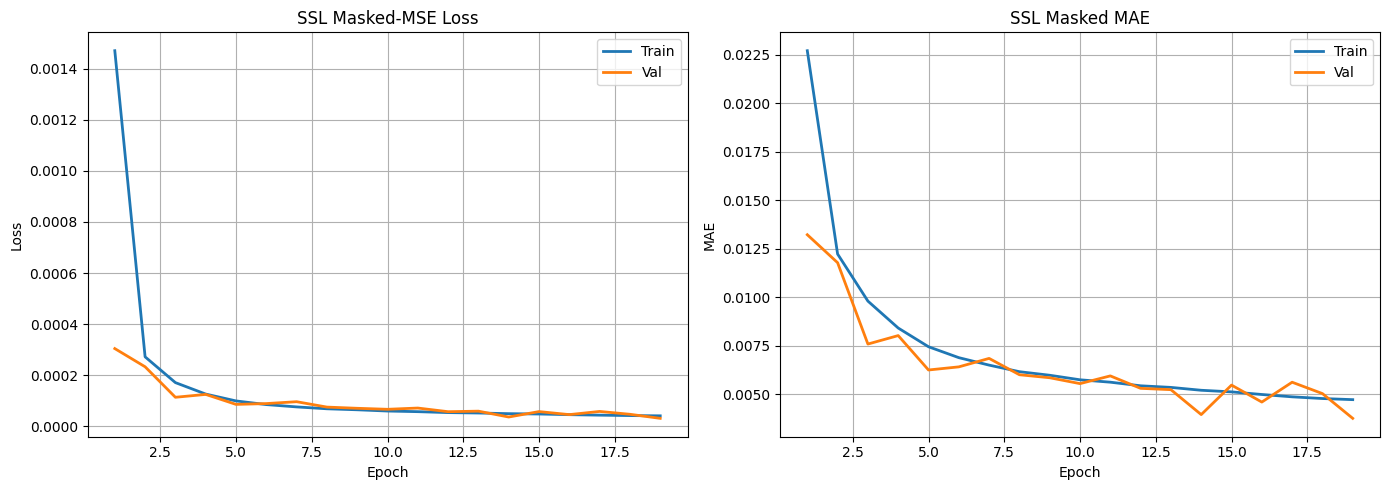

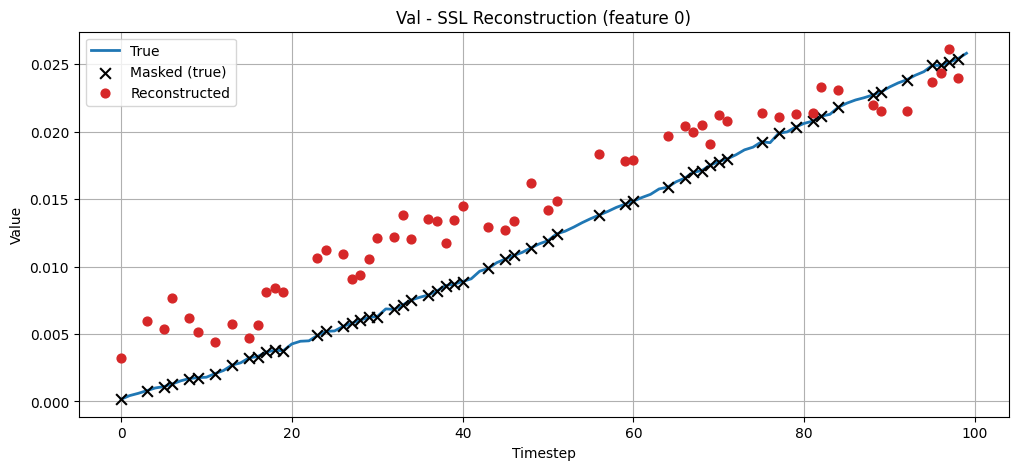

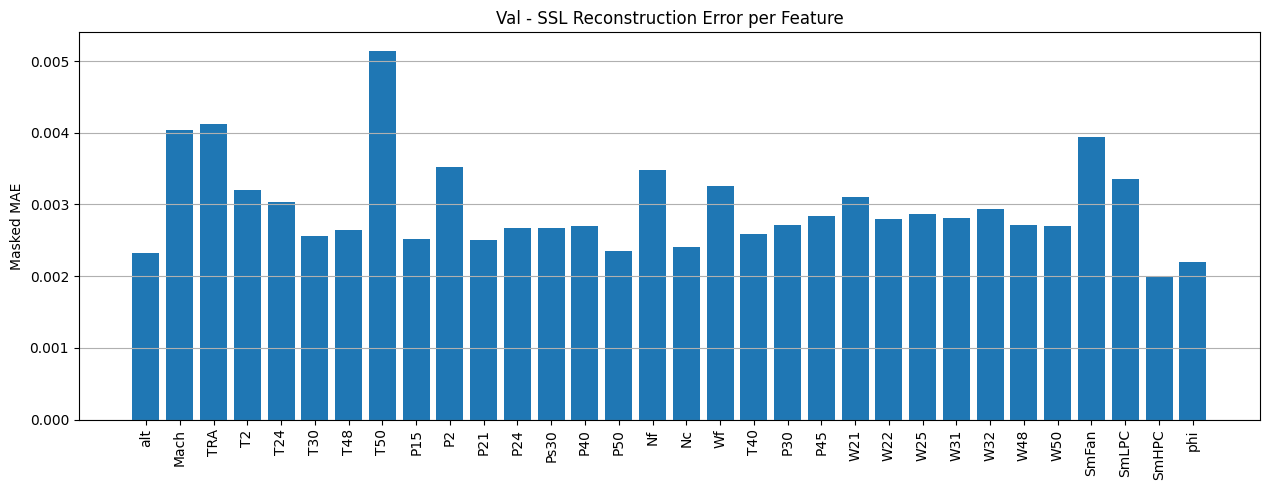

In [11]:
plot_ssl_history(ssl_history)

ssl_model.eval()
with torch.no_grad():
    x_batch = next(iter(ssl_val_loader)).to(device).float()
    pred_batch, mask_batch, _ = ssl_model(x_batch)

plot_ssl_reconstruction(x_batch[0], pred_batch[0], mask_batch[0], feature_idx=0, split_name="Val")
plot_ssl_feature_errors(x_batch, pred_batch, mask_batch, feature_names=features, split_name="Val")


## RUL data preprocessing (DS02)



In [ ]:
*_, ds02_train_df, ds02_test_df = load_data(RUL_FILE)
ds02_train_scaled, ds02_test_scaled, _, _ = preprocessing(True, ds02_train_df, ds02_test_df, features)
del ds02_train_df, ds02_test_df
gc.collect()

rul_train_df = ds02_train_scaled[ds02_train_scaled["unit"] != VAL_UNIT]
rul_val_df = ds02_train_scaled[ds02_train_scaled["unit"] == VAL_UNIT]

rul_train_set = CMAPSSWindowed(rul_train_df, features, window_size=50, stride=15, has_target=True) 
rul_val_set = CMAPSSWindowed(rul_val_df, features, window_size=50, stride=15, has_target=True)
rul_test_set = CMAPSSWindowed(ds02_test_scaled, features, window_size=50, stride=15, has_target=True)

print(f"RUL train windows: {len(rul_train_set)} | val windows: {len(rul_val_set)} | test windows: {len(rul_test_set)}")



Operation time (min):  0.03125

W_dev shape: (5263447, 4) | W_test shape: (1253743, 4)
X_s_dev shape: (5263447, 14) | X_s_test shape: (1253743, 14)
X_v_dev shape: (5263447, 14) | X_v_test shape: (1253743, 14)
A_dev shape: (5263447, 4) | A_test shape: (1253743, 4)
Data Normalization

RUL train windows: 291501 | val windows: 59378 | test windows: 83574


## Study 2: RUL GP head


In [ ]:
RUL_SEARCH_EPOCHS = 10

window_size = best_ssl["window_size"]
stride = int(window_size * best_ssl["stride_ratio"])

def rul_objective(trial):
    num_inducing = trial.suggest_categorical("num_inducing", [100, 200, 400, 1000]) 
    batch_size = trial.suggest_categorical("rul_batch_size", [32, 64, 128])
    lr = trial.suggest_float("rul_lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("rul_weight_decay", 1e-6, 1e-3, log=True)
    freeze = trial.suggest_categorical("freeze_backbone", [True, False])

    train_loader = DataLoader(rul_train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(rul_val_set, batch_size=batch_size, shuffle=False)

    trial_backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)
    load_pretrained_backbone(trial_backbone, SSL_CHECKPOINT, device, freeze=freeze)

    inducing_points = init_inducing_points(trial_backbone, train_loader, device, num_inducing=num_inducing)
    model = RULHead(trial_backbone, trial_backbone.d_model, inducing_points=inducing_points).to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )

    print(f"=============================== trial{trial.number} =================================")
    print(trial_backbone)
    print(f"num_inducing: {num_inducing}, freeze: {freeze}, LR: {lr}, Weight Decay: {weight_decay}, Batch Size: {batch_size}, dimension: {trial_backbone.d_model}")
    for _ in range(RUL_SEARCH_EPOCHS):
        train_rul(model, train_loader, optimizer, device)
    val_metrics = test_rul(model, val_loader, device)

    if not math.isfinite(val_metrics["rmse"]):
        
        del model, trial_backbone, optimizer, train_loader, val_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        raise optuna.TrialPruned()

    del model, trial_backbone, optimizer, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return val_metrics["rmse"]


study_rul = optuna.create_study(direction="minimize", study_name="rul_all_sensors")
study_rul.optimize(rul_objective, n_trials=15)

print("Best RUL trial:", study_rul.best_trial.number)
print("Best params:", study_rul.best_params)
print("Best val RMSE:", study_rul.best_value)


### Final RUL retrain with the winning Study 2 config

In [ ]:
best_rul = {'num_inducing': 400,
            'rul_batch_size': 64, 
            'rul_lr': 0.000872032514386617, 
            'rul_weight_decay': 0.0007192677422438842, 
            'freeze_backbone': False
            } # best params are from optuna

In [13]:
rul_model

RULHead(
  (backbone): TCNTransformerBackbone(
    (tcn): Sequential(
      (0): TemporalBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (chomp1): Chomp1d()
        (relu1): ReLU()
        (drop1): Dropout(p=0.22281121542606983, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (chomp2): Chomp1d()
        (relu2): ReLU()
        (drop2): Dropout(p=0.22281121542606983, inplace=False)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        (relu): ReLU()
      )
      (1): TemporalBlock(
        (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (chomp1): Chomp1d()
        (relu1): ReLU()
        (drop1): Dropout(p=0.22281121542606983, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (chomp2): Chomp1d()
        (relu2): ReLU()
        (drop2): Dropout(p=0.222811215426069

In [ ]:
#best_rul = study_rul.best_params
RUL_FINAL_EPOCHS = 60

rul_train_loader = DataLoader(rul_train_set, batch_size=best_rul["rul_batch_size"], shuffle=True)
rul_val_loader = DataLoader(rul_val_set, batch_size=best_rul["rul_batch_size"], shuffle=False)

rul_backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)
load_pretrained_backbone(rul_backbone, SSL_CHECKPOINT, device, freeze=best_rul["freeze_backbone"])

inducing_points = init_inducing_points(rul_backbone, rul_train_loader, device, num_inducing=best_rul["num_inducing"])
rul_model = RULHead(rul_backbone, rul_backbone.d_model, inducing_points=inducing_points).to(device)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, rul_model.parameters()),
    lr=best_rul["rul_lr"], weight_decay=best_rul["rul_weight_decay"]
)

early_stopper = EarlyStopping(patience=8, min_delta=1e-4, save_path=RUL_CHECKPOINT)
rul_train_history, rul_val_history = [], []

for epoch in range(RUL_FINAL_EPOCHS):
    train_metrics = train_rul(rul_model, rul_train_loader, optimizer, device)
    val_metrics = test_rul(rul_model, rul_val_loader, device) 
    rul_train_history.append(train_metrics)
    rul_val_history.append(val_metrics)

    print(f"Epoch {epoch+1}/{RUL_FINAL_EPOCHS} | "
          f"train_loss={train_metrics['loss']:.4f} train_r2={train_metrics['r2']:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} val_rmse={val_metrics['rmse']:.4f} val_r2={val_metrics['r2']:.4f} | "
          f"time={train_metrics['time']:.2f}s")

    early_stopper(val_metrics["loss"], rul_model)
    if early_stopper.early_stop:
        print("Early stopping triggered")
        break

if early_stopper.has_saved:
    rul_model.load_state_dict(torch.load(early_stopper.save_path))
else:
    print(f"Warning: RUL head training never improved on the initial loss (likely diverged/NaN) - "
          f"no checkpoint was saved to {early_stopper.save_path}, keeping the last epoch's weights.")


[RUL Train] Loss: 239.3755 - RMSE: 21.9586 - NASA mean: 9.7194 - NASA total: 2833222.14 - Time: 80.82s
[RUL Test] Loss: 20.7621 - RMSE: 7.4897 - R2: 0.8702 - NASA mean: 0.8433 - NASA total: 50073.76 - Time: 5.10s
Epoch 1/60 | train_loss=239.3755 train_r2=0.0588 | val_loss=20.7621 val_rmse=7.4897 val_r2=0.8702 | time=80.82s
[RUL Train] Loss: 40.2287 - RMSE: 10.9991 - NASA mean: 1.5493 - NASA total: 451619.88 - Time: 77.70s
[RUL Test] Loss: 10.2286 - RMSE: 5.6555 - R2: 0.9260 - NASA mean: 0.5789 - NASA total: 34374.39 - Time: 5.12s
Epoch 2/60 | train_loss=40.2287 train_r2=0.7639 | val_loss=10.2286 val_rmse=5.6555 val_r2=0.9260 | time=77.70s
[RUL Train] Loss: 23.8398 - RMSE: 10.2081 - NASA mean: 1.4143 - NASA total: 412281.50 - Time: 76.91s
[RUL Test] Loss: 15.3701 - RMSE: 9.4936 - R2: 0.7914 - NASA mean: 1.5762 - NASA total: 93590.52 - Time: 4.95s
Epoch 3/60 | train_loss=23.8398 train_r2=0.7966 | val_loss=15.3701 val_rmse=9.4936 val_r2=0.7914 | time=76.91s
[RUL Train] Loss: 12.4699 - RMS

### RUL training curves

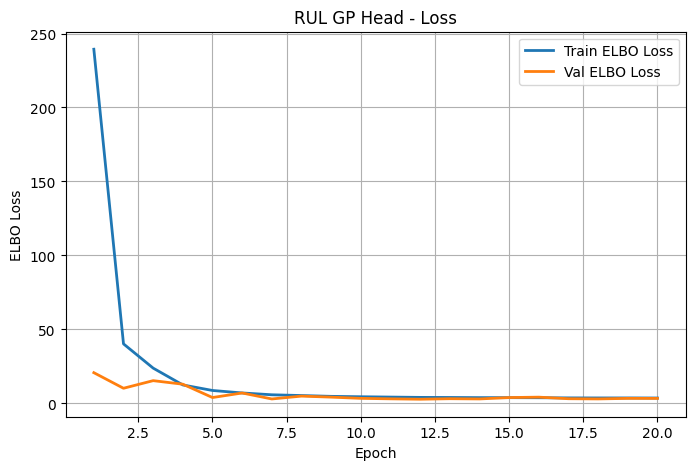

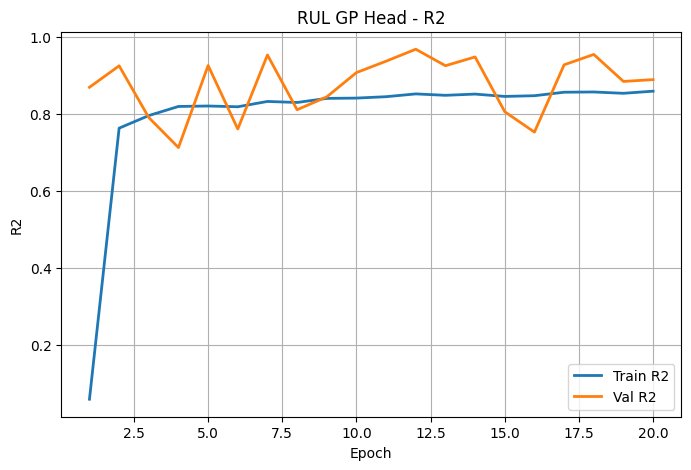

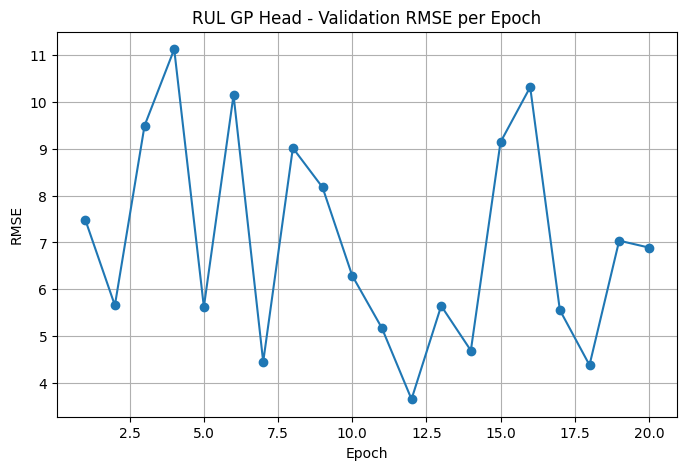

In [ ]:
plot_metric_curve([h["loss"] for h in rul_train_history], [h["loss"] for h in rul_val_history],
                   metric_name="ELBO Loss", title="RUL GP Head - Loss")
plot_metric_curve([h["r2"] for h in rul_train_history], [h["r2"] for h in rul_val_history],
                   metric_name="R2", title="RUL GP Head - R2")


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rul_val_history) + 1), [h["rmse"] for h in rul_val_history], marker="o")
plt.xlabel("Epoch"); plt.ylabel("RMSE")
plt.title("RUL GP Head - Validation RMSE per Epoch")
plt.grid(True)
plt.show()


## Final RUL test evaluation


[RUL Test] Loss: 3.0998 - RMSE: 5.2989 - R2: 0.9219 - NASA mean: 0.5374 - NASA total: 44911.48 - Time: 7.48s
{'loss': 3.09983781486704, 'rmse': 5.298905372619629, 'r2': 0.9219250082969666, 'nasa_mean': 0.537385748707732, 'nasa_total': 44911.4765625, 'time': 7.479116439819336}


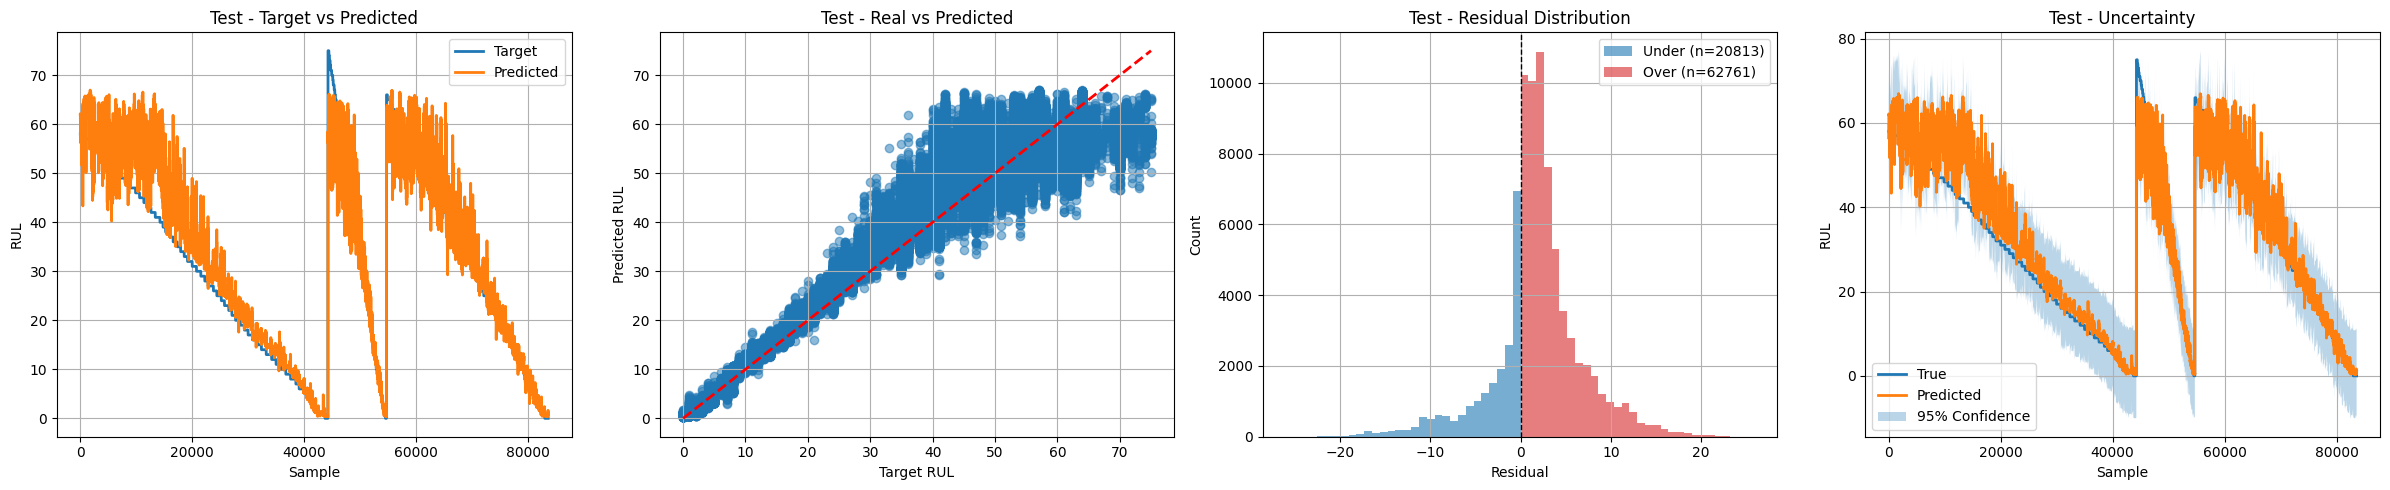

In [16]:
rul_test_loader = DataLoader(rul_test_set, batch_size=best_rul["rul_batch_size"], shuffle=False)
final_rul_metrics = test_rul(rul_model, rul_test_loader, device)

print({k: v for k, v in final_rul_metrics.items() if k not in ("preds", "targets", "std")})

plot_regression_dashboard(
    final_rul_metrics["targets"], final_rul_metrics["preds"],
    std=final_rul_metrics["std"], split_name="Test"
)


## Anomaly detection / classification head


In [ ]:
best_ssl = {
    'window_size': 100,
    'stride_ratio': 0.3,
    'mask_ratio': 0.5,
    'lr': 0.0023273349952157556,
    'weight_decay': 3.856567160779227e-06,
    'batch_size': 64,
    'backbone_type': 'tcn_transformer',
    'dropout': 0.22281121542606983,
    'hyb_tcn_channels': 64,
    'hyb_d_model': 128,
    'hyb_nhead': 8,
    'hyb_num_layers': 2,
    'hyb_dim_feedforward': 128,
}  # this are from optuna

In [ ]:
window_size =  best_ssl['window_size']
stride_ratio = best_ssl['stride_ratio']
stride = int(window_size * stride_ratio) 

*_, ds02_train_df, ds02_test_df = load_data(RUL_FILE)
ds02_train_scaled, ds02_test_scaled, _, _ = preprocessing(True, ds02_train_df, ds02_test_df, features)
del ds02_train_df, ds02_test_df
gc.collect()

cls_train_df = ds02_train_scaled[ds02_train_scaled["unit"] != VAL_UNIT]
cls_val_df = ds02_train_scaled[ds02_train_scaled["unit"] == VAL_UNIT]

cls_train_set = CMAPSSWindowed(cls_train_df, features, window_size, stride, has_target=True, target_col="hs")
cls_val_set = CMAPSSWindowed(cls_val_df, features, window_size, stride, has_target=True, target_col="hs")
cls_test_set = CMAPSSWindowed(ds02_test_scaled, features, window_size, stride, has_target=True, target_col="hs")

print(f"CLS train windows: {len(cls_train_set)} | val windows: {len(cls_val_set)} | test windows: {len(cls_test_set)}")


Operation time (min):  0.026041666666666668

W_dev shape: (5263447, 4) | W_test shape: (1253743, 4)
X_s_dev shape: (5263447, 14) | X_s_test shape: (1253743, 14)
X_v_dev shape: (5263447, 14) | X_v_test shape: (1253743, 14)
A_dev shape: (5263447, 4) | A_test shape: (1253743, 4)
Data Normalization

CLS train windows: 145744 | val windows: 29688 | test windows: 41783


In [8]:
CLS_SEARCH_EPOCHS = 10

window_size = best_ssl["window_size"]
stride = int(window_size * best_ssl["stride_ratio"])


def cls_objective(trial):
    num_inducing = trial.suggest_categorical("num_inducing", [100, 200, 400, 1000])
    batch_size = trial.suggest_categorical("cls_batch_size", [32, 64, 128, 256])
    lr = trial.suggest_float("cls_lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("cls_weight_decay", 1e-6, 1e-3, log=True)
    freeze = trial.suggest_categorical("freeze_backbone", [True, False])

    train_loader = DataLoader(cls_train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(cls_val_set, batch_size=batch_size, shuffle=False)

    trial_backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers=best_ssl["hyb_num_layers"],
        num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
        dropout=best_ssl["dropout"],
        d_model=best_ssl["hyb_d_model"],
        nhead=best_ssl["hyb_nhead"],
        dim_feedforward=best_ssl["hyb_dim_feedforward"],
    ).to(device)

    load_pretrained_backbone(trial_backbone, SSL_CHECKPOINT, device, freeze=freeze)

    inducing_points = init_inducing_points(trial_backbone, train_loader, device, num_inducing=num_inducing)
    model = BinaryClassificationHead(trial_backbone, trial_backbone.d_model,
                                     inducing_points=inducing_points).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )

    print(f"=============================== cls_trial{trial.number} =================================")
    print(trial_backbone)
    print(f"num_inducing: {num_inducing}, freeze: {freeze}, LR: {lr:.2e}, "
          f"Weight Decay: {weight_decay:.2e}, Batch Size: {batch_size}, dimension: {trial_backbone.d_model}")

    try:
        for _ in range(CLS_SEARCH_EPOCHS):
            train_cls(model, train_loader, optimizer, device)
        val_metrics = test_cls(model, val_loader, device)
    except Exception as e:
        if "NanError" in type(e).__name__ or "cholesky" in str(e).lower():
            del model, trial_backbone, optimizer, train_loader, val_loader
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            raise optuna.TrialPruned()
        raise

    f1 = val_metrics["f1"]

    del model, trial_backbone, optimizer, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if not math.isfinite(f1):
        raise optuna.TrialPruned()

    return f1


study_cls = optuna.create_study(direction="maximize", study_name="mehdi_cls_all_sensors")
study_cls.optimize(cls_objective, n_trials=10)

print("Best CLS trial:", study_cls.best_trial.number)
print("Best params:", study_cls.best_params)
print("Best val F1:", study_cls.best_value)

=============================== cls_trial0 =================================
TCNTransformerBackbone(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.22281121542606983, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.22281121542606983, inplace=False)
      (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.22281121542606983, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.22281

In [ ]:
best_cls = {
    "num_inducing": 100,
    "freeze_backbone": False,
    "cls_lr": 0.0016014512960402035, 
    "cls_weight_decay": 4.022229816585826e-06,
    "cls_batch_size": 64
} # from optuna bests

In [14]:
CLS_EPOCHS = 40


cls_train_loader = DataLoader(cls_train_set, batch_size=best_cls["cls_batch_size"], shuffle=True)
cls_val_loader = DataLoader(cls_val_set, batch_size=best_cls["cls_batch_size"], shuffle=False)

cls_backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers=best_ssl["hyb_num_layers"],
        num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
        dropout=best_ssl["dropout"],
        d_model=best_ssl["hyb_d_model"],
        nhead=best_ssl["hyb_nhead"],
        dim_feedforward=best_ssl["hyb_dim_feedforward"],
    ).to(device)

load_pretrained_backbone(cls_backbone, SSL_CHECKPOINT, device, freeze=best_cls["freeze_backbone"])


inducing_points = init_inducing_points(cls_backbone, cls_train_loader, device, num_inducing=best_cls["num_inducing"])
cls_model = BinaryClassificationHead(cls_backbone, cls_backbone.d_model, inducing_points=inducing_points).to(device)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cls_model.parameters()),
    lr=best_cls["cls_lr"], weight_decay=best_cls["cls_weight_decay"]
)

cls_early_stopper = EarlyStopping(patience=5, min_delta=1e-4, save_path=CLS_CHECKPOINT)

for epoch in range(CLS_EPOCHS):
    train_metrics = train_cls(cls_model, cls_train_loader, optimizer, device)
    val_metrics = test_cls(cls_model, cls_val_loader, device)

    print(f"Epoch {epoch+1}/{CLS_EPOCHS} | train_loss={train_metrics['loss']:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} "
          f"f1={val_metrics['f1']:.4f} ece={val_metrics['ece']:.4f} time={train_metrics['time']:.2f}s")

    cls_early_stopper(val_metrics["loss"], cls_model)
    if cls_early_stopper.early_stop:
        print("Early stopping triggered")
        break

if cls_early_stopper.has_saved:
    cls_model.load_state_dict(torch.load(cls_early_stopper.save_path))
else:
    print(f"Warning: classification head training never improved on the initial loss (likely diverged/NaN) - "
          f"no checkpoint was saved to {cls_early_stopper.save_path}, keeping the last epoch's weights.")



[CLS Train] Loss: 0.4326 - Time: 43.80s
[CLS Test] Loss: 1.1086 - Accuracy: 0.7790 - F1: 0.0003 - Precision: 0.0081 - Recall: 0.0002 - AUROC: 0.8192 - Brier: 0.2118 - ECE: 0.2131 - Time: 3.32s
Epoch 1/40 | train_loss=0.4326 | val_loss=1.1086 acc=0.7790 f1=0.0003 ece=0.2131 time=43.80s
[CLS Train] Loss: 0.3816 - Time: 41.37s
[CLS Test] Loss: 0.3201 - Accuracy: 0.8199 - F1: 0.3603 - Precision: 0.7848 - Recall: 0.2339 - AUROC: 0.9116 - Brier: 0.1085 - ECE: 0.0426 - Time: 3.41s
Epoch 2/40 | train_loss=0.3816 | val_loss=0.3201 acc=0.8199 f1=0.3603 ece=0.0426 time=41.37s
[CLS Train] Loss: 0.3649 - Time: 42.59s
[CLS Test] Loss: 0.3924 - Accuracy: 0.7674 - F1: 0.6393 - Precision: 0.4817 - Recall: 0.9500 - AUROC: 0.8990 - Brier: 0.1385 - ECE: 0.0669 - Time: 3.46s
Epoch 3/40 | train_loss=0.3649 | val_loss=0.3924 acc=0.7674 f1=0.6393 ece=0.0669 time=42.59s
[CLS Train] Loss: 0.3599 - Time: 41.67s
[CLS Test] Loss: 0.2696 - Accuracy: 0.8726 - F1: 0.7513 - Precision: 0.6515 - Recall: 0.8873 - AUROC: 

[CLS Test] Loss: 0.3768 - Accuracy: 0.7713 - F1: 0.5108 - Precision: 0.9771 - Recall: 0.3458 - AUROC: 0.9760 - Brier: 0.1312 - ECE: 0.0924 - Time: 5.15s
{'loss': 0.376840685964808, 'accuracy': 0.7712945456286049, 'f1': 0.5108016791235794, 'precision': 0.9770857814336075, 'recall': 0.3457859717216523, 'brier': 0.13122068345546722, 'ece': 0.09238835038148324, 'time': 5.150600433349609, 'auroc': 0.9759825074084454}


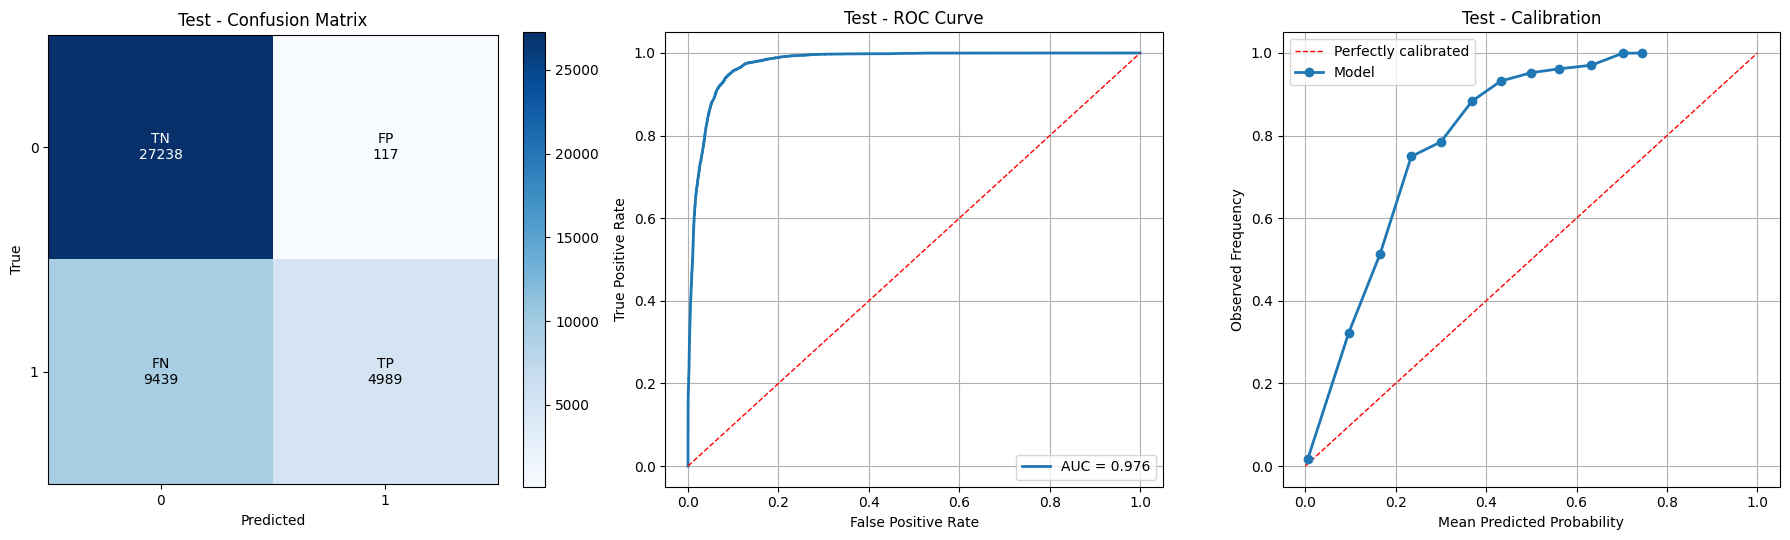

In [15]:
cls_test_loader = DataLoader(cls_test_set, batch_size=best_cls["cls_batch_size"], shuffle=False)
final_cls_metrics = test_cls(cls_model, cls_test_loader, device)

print({k: v for k, v in final_cls_metrics.items() if k not in ("probs", "targets")})

plot_classification_dashboard(final_cls_metrics["targets"], final_cls_metrics["probs"], split_name="Test")